# LightGBM

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

X, y = make_friedman1(n_samples=20_000, n_features=10, noise=1.0, random_state=0)
X = pd.DataFrame(X, columns=[f"x{i}" for i in range(10)])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.3, random_state=0)
print(X_tr.shape, X_va.shape, X_te.shape)

(9800, 10) (4200, 10) (6000, 10)


## 1. Basic usage

Two APIs: the scikit-learn wrapper (`LGBMRegressor` / `LGBMClassifier`) and the native one (`lgb.Dataset` + `lgb.train`). Early stopping is done via callbacks.

sklearn API  best_iter: 291  test RMSE: 1.104
native API   best_iter: 291  test RMSE: 1.104


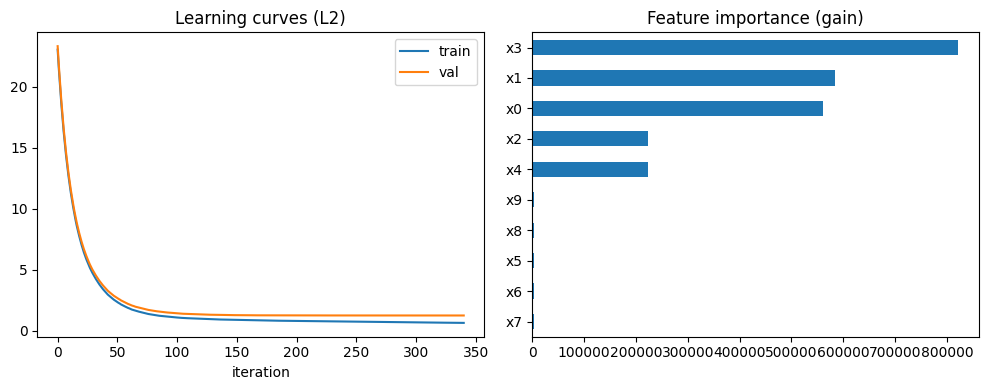

In [5]:
model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=31, verbose=-1)
model.fit(X_tr, y_tr, eval_X=X_va, eval_y=y_va,
          callbacks=[lgb.early_stopping(50, verbose=False)])
print("sklearn API  best_iter:", model.best_iteration_, " test RMSE:", round(rmse(y_te, model.predict(X_te)), 3))

dtrain = lgb.Dataset(X_tr, y_tr)
dval = lgb.Dataset(X_va, y_va, reference=dtrain) 
params = dict(objective="regression", learning_rate=0.05, num_leaves=31, verbose=-1)
evals = {}
booster = lgb.train(params, dtrain, num_boost_round=1000, valid_sets=[dtrain, dval],
                    valid_names=["train", "val"],
                    callbacks=[lgb.early_stopping(50, verbose=False), lgb.record_evaluation(evals)])
print("native API   best_iter:", booster.best_iteration, " test RMSE:", round(rmse(y_te, booster.predict(X_te)), 3))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for k in evals: ax[0].plot(evals[k]["l2"], label=k)
ax[0].set(title="Learning curves (L2)", xlabel="iteration"); ax[0].legend()
imp = pd.Series(booster.feature_importance("gain"), index=X.columns).sort_values()
imp.plot.barh(ax=ax[1], title="Feature importance (gain)")
plt.tight_layout()
plt.show()

## 2. Histogram binning

Exact greedy GBDT sorts every feature and scans all `n` thresholds per split. LightGBM first **discretises each feature into at most `max_bin` (default 255) bins**, once, before training. Afterwards:

* a feature is stored as a `uint8`/`uint16` column
* finding the best split for one feature costs `O(bins)` over a gradient histogram instead of `O(n)`
* the **histogram subtraction trick**: `hist(sibling) = hist(parent) − hist(smaller child)`, so only the smaller child's histogram is built from data.

Bin boundaries come from (roughly) quantiles, so bins are dense where the data is dense.

distinct raw values: 9800 -> bins: 16
subtraction trick exact: True


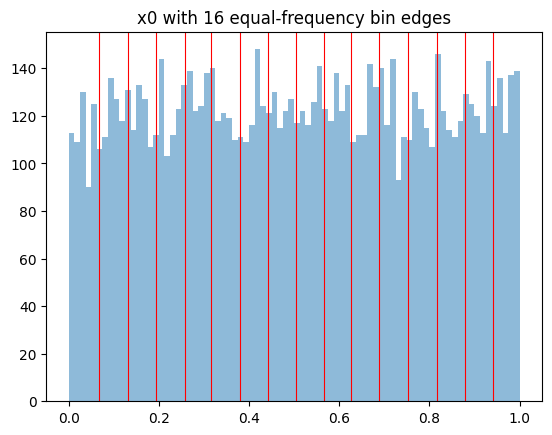

In [ ]:
x = X_tr["x0"].values
edges = np.unique(np.quantile(x, np.linspace(0, 1, 17)[1:-1]))
bins = np.searchsorted(edges, x)
print("distinct raw values:", len(np.unique(x)), "-> bins:", len(np.unique(bins)))

g = np.random.default_rng(0).normal(size=len(x))
left = x < np.median(x)
H = lambda mask: np.bincount(bins[mask], weights=g[mask], minlength=16)
print("subtraction trick exact:", np.allclose(H(np.ones_like(left)) - H(left), H(~left)))

plt.hist(x, bins=80, alpha=.5); [plt.axvline(e, c="r", lw=.8) for e in edges]
plt.title("x0 with 16 equal-frequency bin edges"); plt.show()

## 3. Breadth-first (level-wise) vs best-first (leaf-wise)

* **Level-wise / breadth-first** (XGBoost's default `grow_policy=depthwise`, sklearn GBDT): split *every* node at depth `d` before moving to `d+1`. Trees are balanced; some splits have tiny gain but are made anyway.
* **Leaf-wise / best-first** (LightGBM): among *all current leaves*, split the one with the **largest loss reduction**, repeat until `num_leaves` is reached. For the same number of leaves it reaches a lower training loss, but trees become **deep and lopsided**, which overfits easily on small data.

Therefore the key knob is `num_leaves`, not `max_depth`. Keep `num_leaves < 2^max_depth`, otherwise `max_depth` has no effect. Section 7 implements both policies side by side.

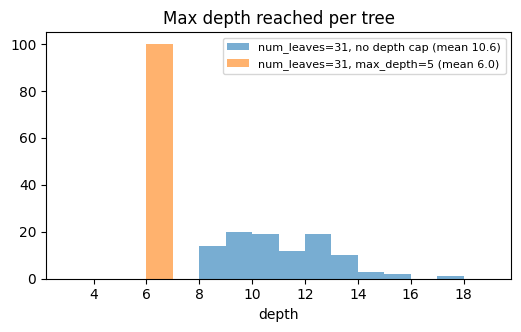

In [8]:
def tree_depths(booster):
    df = booster.trees_to_dataframe()
    return df.groupby("tree_index")["node_depth"].max()

fig, ax = plt.subplots(figsize=(6, 3.2))
for label, kw in {"num_leaves=31, no depth cap": dict(num_leaves=31, max_depth=-1),
                  "num_leaves=31, max_depth=5": dict(num_leaves=31, max_depth=5)}.items():
    b = lgb.train(dict(objective="regression", learning_rate=0.1, verbose=-1, **kw), dtrain, 100)
    d = tree_depths(b)
    ax.hist(d, bins=range(3, 20), alpha=.6, label=f"{label} (mean {d.mean():.1f})")
ax.set(title="Max depth reached per tree", xlabel="depth"); ax.legend(fontsize=8); plt.show()

## 4. GOSS: Gradient-based One-Side Sampling

Rows with small gradients are already well fit and contribute little to information gain. GOSS:

1. sort rows by `|gradient|`,
2. keep the top `a` fraction (large gradients),
3. randomly sample a `b` fraction from the rest,
4. **multiply the sampled small-gradient rows by `(1−a)/b`** so the data distribution (and gain estimate) is not biased.

Compared with uniform subsampling, the estimate of split gain has lower variance for the same number of rows. In LightGBM ≥ 4.0 use `data_sample_strategy="goss"` with `top_rate=a`, `other_rate=b` (the old `boosting_type="goss"` is deprecated).

In [ ]:
rng = np.random.default_rng(1)
n, a, b = 100_000, 0.2, 0.1
g = rng.standard_t(df=2, size=n)
left = rng.random(n) < 0.3
true = g[left].sum()

def goss_est(g, left):
    order = np.argsort(-np.abs(g))
    top = order[: int(a * n)]
    rest = rng.choice(order[int(a * n):], int(b * n), replace=False)
    w = (1 - a) / b
    return g[top][left[top]].sum() + w * g[rest][left[rest]].sum()

def uniform_est(g, left):
    s = rng.choice(n, int((a + b) * n), replace=False)
    return g[s][left[s]].sum() / (a + b)

err = lambda f: np.mean([abs(f(g, left) - true) for _ in range(300)])
print(f"mean |error|  GOSS: {err(goss_est):.1f}   uniform (same #rows): {err(uniform_est):.1f}   (true G_L = {true:.1f})")

mean |error|  GOSS: 268.6   uniform (same #rows): 654.4   (true G_L = -1198.6)


*Note:* on 12k rows GOSS is not faster (sampling overhead dominates, and the first rounds use all rows); the benefit appears at millions of rows. The accuracy being on par is the point here.

## 5. EFB: Exclusive Feature Bundling

In high-dimensional sparse data (one-hot encodings, count features), many features are **never non-zero at the same time**. EFB merges such features into one by **offsetting their bin ranges** so values stay distinguishable: feature A occupies bins `1..kA`, feature B `kA+1..kA+kB`, and so on. Histogram cost then scales with the number of *bundles*, not features.

Finding the optimal bundling is NP-hard (graph colouring), so LightGBM uses a greedy algorithm: build a conflict graph (edge weight = rows where both are non-zero), sort features by degree, put each in the first bundle where conflicts stay `≤ max_conflict_rate · n`. Allowing a few conflicts trades a little accuracy for fewer bundles.

In [ ]:
rng = np.random.default_rng(0)
n = 5000
cats = rng.integers(0, 10, size=(n, 3))
onehot = np.zeros((n, 30), dtype=np.int8)
for j in range(3): onehot[np.arange(n), j * 10 + cats[:, j]] = 1

def greedy_bundles(M, max_conflicts=0):
    nz = (M != 0).astype(np.int32)
    conflict = nz.T @ nz; np.fill_diagonal(conflict, 0)
    order = np.argsort(-conflict.sum(1))
    bundles = []
    for f in order:
        for b in bundles:
            if conflict[f, b].sum() <= max_conflicts: b.append(f); break
        else: bundles.append([f])
    return bundles

bundles = greedy_bundles(onehot)
print("30 features ->", len(bundles), "bundles; sizes:", [len(b) for b in bundles])

merged = np.zeros((n, len(bundles)), dtype=np.int16)
for k, b in enumerate(bundles):
    for off, f in enumerate(b, start=1):
        merged[onehot[:, f] != 0, k] = off
print("merged shape:", merged.shape, "| first row original nonzero cols:", np.flatnonzero(onehot[0]),
      "-> merged codes:", merged[0])

30 features -> 3 bundles; sizes: [10, 10, 10]
merged shape: (5000, 3) | first row original nonzero cols: [ 8 16 25] -> merged codes: [10  6  2]
